<a href="https://colab.research.google.com/github/Yashika299/Yashika299/blob/main/sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Pandas library

In [62]:
import pandas as pd

In [63]:
import matplotlib.dates as mdates

Load Dataset

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
df = pd.read_csv('https://raw.githubusercontent.com/Yashika299/Yashika299/refs/heads/main/superstore.csv')

In [66]:
# Remove unwanted column
df.drop(columns=['记录数'], inplace=True, errors='ignore')

first 5 rows

In [67]:
print(df.head())

          Category         City        Country Customer.ID     Customer.Name  \
0  Office Supplies  Los Angeles  United States   LS-172304  Lycoris Saunders   
1  Office Supplies  Los Angeles  United States   MV-174854     Mark Van Huff   
2  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
3  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
4  Office Supplies  Los Angeles  United States   AP-109154    Arthur Prichep   

   Discount Market               Order.Date        Order.ID Order.Priority  \
0       0.0     US  2011-01-07 00:00:00.000  CA-2011-130813           High   
1       0.0     US  2011-01-21 00:00:00.000  CA-2011-148614         Medium   
2       0.0     US  2011-08-05 00:00:00.000  CA-2011-118962         Medium   
3       0.0     US  2011-08-05 00:00:00.000  CA-2011-118962         Medium   
4       0.0     US  2011-09-29 00:00:00.000  CA-2011-146969           High   

   ... Sales   Segment                Ship.Date   

Check Columns

In [68]:
print(df.columns)

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')


Check basic info

In [69]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   Order.Date      51290 non-null  object 
 8   Order.ID        51290 non-null  object 
 9   Order.Priority  51290 non-null  object 
 10  Product.ID      51290 non-null  object 
 11  Product.Name    51290 non-null  object 
 12  Profit          51290 non-null  float64
 13  Quantity        51290 non-null  int64  
 14  Region          51290 non-null  object 
 15  Row.ID          51290 non-null  int64  
 16  Sales           51290 non-null  int64  
 17  Segment         51290 non-null 

Convert Date Column

In [70]:
df['Order.Date'] = pd.to_datetime(df['Order.Date'])
df['Ship.Date'] = pd.to_datetime(df['Ship.Date'])
## the date columns are converted into the datetime format to enable time-based analysis such as monthly and yearly trends.

Creating Month and Year Columns

In [71]:
df['Month'] = df['Order.Date'].dt.month
df['Year'] = df['Order.Date'].dt.year
df['Month_Year'] = df['Order.Date'].dt.to_period('M')
## new columns such as Month, Year, and Month-Year were created to analyze sales trends over time.

Checking for duplicacy

In [72]:
print(df.duplicated().sum())
## The dataset was checked for duplicate records and duplicates were removed to avoid incorrect analysis.

0


Remove Unnecessary Columns

In [73]:
df = df.drop(['Customer.Name', 'Row.ID', 'Customer.ID'], axis=1)
## Unnecessary columns that do not contribute to sales analysis were removed to simplify the dataset.

Final Check

In [74]:
print(df.info())
## after cleaning, the dataset was verified to ensure correct datatypes and structure.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  object        
 1   City            51290 non-null  object        
 2   Country         51290 non-null  object        
 3   Discount        51290 non-null  float64       
 4   Market          51290 non-null  object        
 5   Order.Date      51290 non-null  datetime64[ns]
 6   Order.ID        51290 non-null  object        
 7   Order.Priority  51290 non-null  object        
 8   Product.ID      51290 non-null  object        
 9   Product.Name    51290 non-null  object        
 10  Profit          51290 non-null  float64       
 11  Quantity        51290 non-null  int64         
 12  Region          51290 non-null  object        
 13  Sales           51290 non-null  int64         
 14  Segment         51290 non-null  object        
 15  Sh

**Monthly Sales Aggregation**
After cleaning the dataset, the data was grouped on a monthly basis to analyze the overall sales trend. This helps in understanding how sales change over time and identifying patterns such as growth or decline.

In [75]:
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()
# The dataset was grouped by Month-Year and total sales were calculated for each month to observe the monthly sales trend.

In [76]:
print(monthly_sales.head())
# The aggregated dataset shows total sales for each month, which will be used for further trend analysis and visualization.

  Month_Year   Sales
0    2011-01   98902
1    2011-02   91152
2    2011-03  145726
3    2011-04  116927
4    2011-05  146762


In [77]:
monthly_sales = monthly_sales.sort_values('Month_Year')
# The data was sorted in chronological order to ensure accurate trend visualization.

**Data Visualization**
Data visualization was performed to represent monthly sales trends in graphical form. Graphs help in understanding patterns, trends, and fluctuations more effectively than raw data.

Importing libraries

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

**Line Chart**

A line chart was created to visualize the monthly sales trend. It helps in identifying whether sales are increasing, decreasing, or showing seasonal patterns over time.

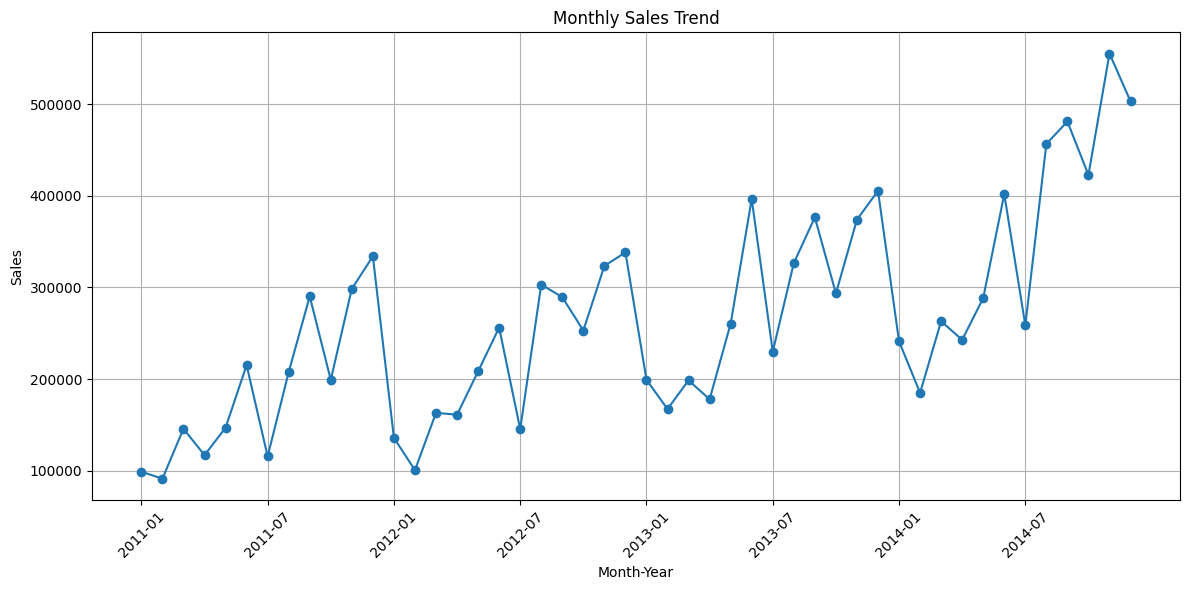

In [79]:
plt.figure(figsize=(12,6))
plt.plot(
    monthly_sales['Month_Year'].astype(str),
    monthly_sales['Sales'],
    marker='o'
)
plt.xticks(
    ticks=range(0, len(monthly_sales), 6),
    labels=monthly_sales['Month_Year'].astype(str)[::6],
    rotation=45
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month-Year")
plt.ylabel("Sales")
plt.grid(True)

plt.tight_layout()

plt.show()

**Bar Chart**

A bar chart was used to compare sales across different months. It clearly shows which months have higher or lower sales.

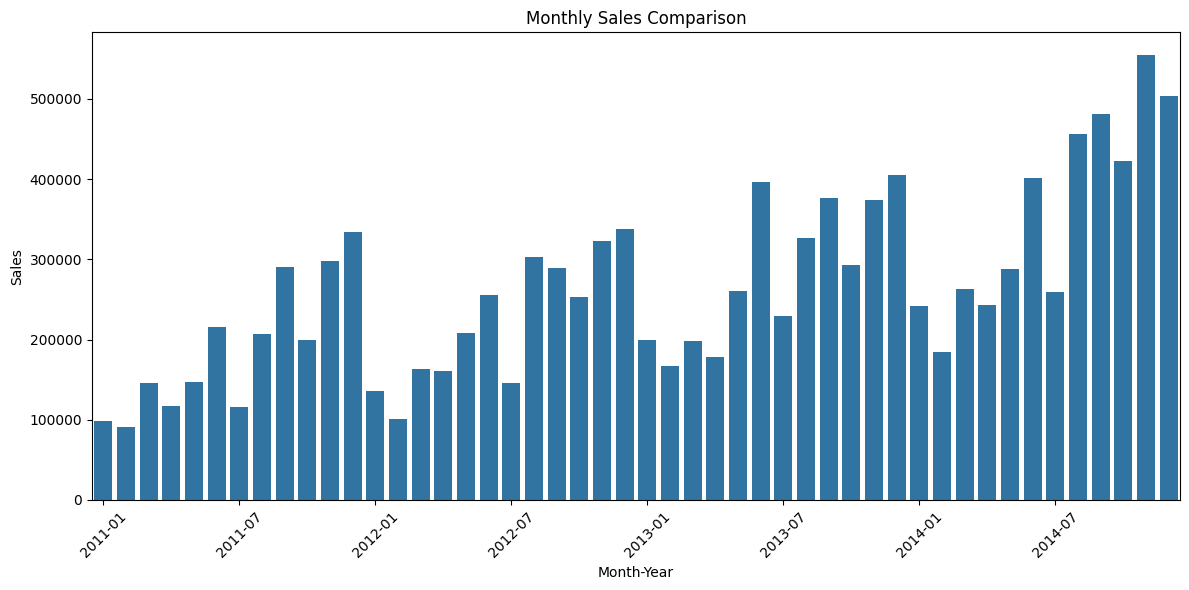

In [80]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=monthly_sales['Month_Year'].astype(str),
    y=monthly_sales['Sales']
)
plt.xticks(
    ticks=range(0, len(monthly_sales), 6),
    labels=monthly_sales['Month_Year'].astype(str)[::6],
    rotation=45
)
plt.title("Monthly Sales Comparison")
plt.xlabel("Month-Year")
plt.ylabel("Sales")

plt.tight_layout()

plt.show()

**Histogram**

A histogram was created to understand the distribution of sales values and identify how frequently certain sales ranges occur.

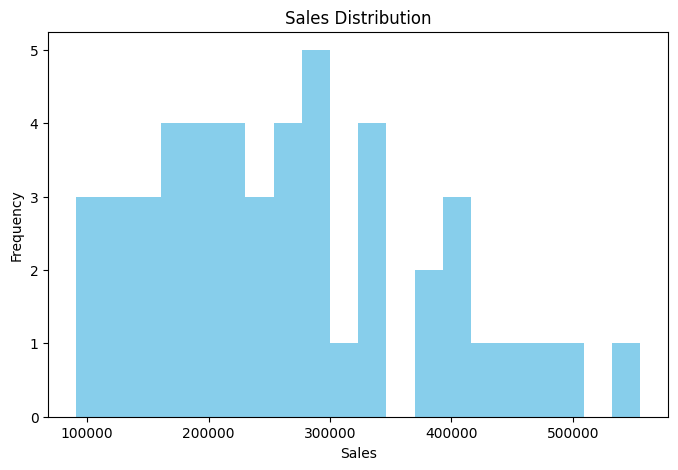

In [81]:
plt.figure(figsize=(8,5))
plt.hist(monthly_sales['Sales'], bins=20, color='skyblue')

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

**Boxplots**

A boxplot was used to detect outliers in the sales data. It helps in identifying unusual spikes or drops in sales.

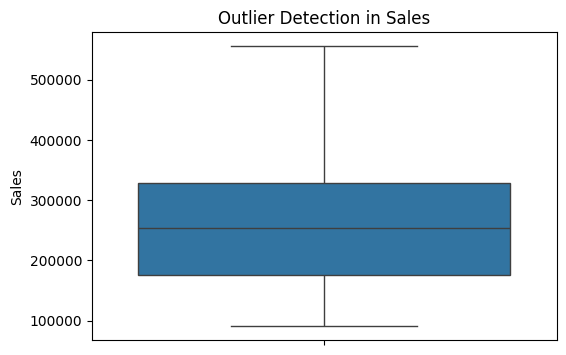

In [82]:
plt.figure(figsize=(6,4))
sns.boxplot(y=monthly_sales['Sales'])

plt.title("Outlier Detection in Sales")

plt.show()

**Sales vs Profit**

This graph compares sales and profit trends over time, helping to understand whether higher sales are generating higher profits.

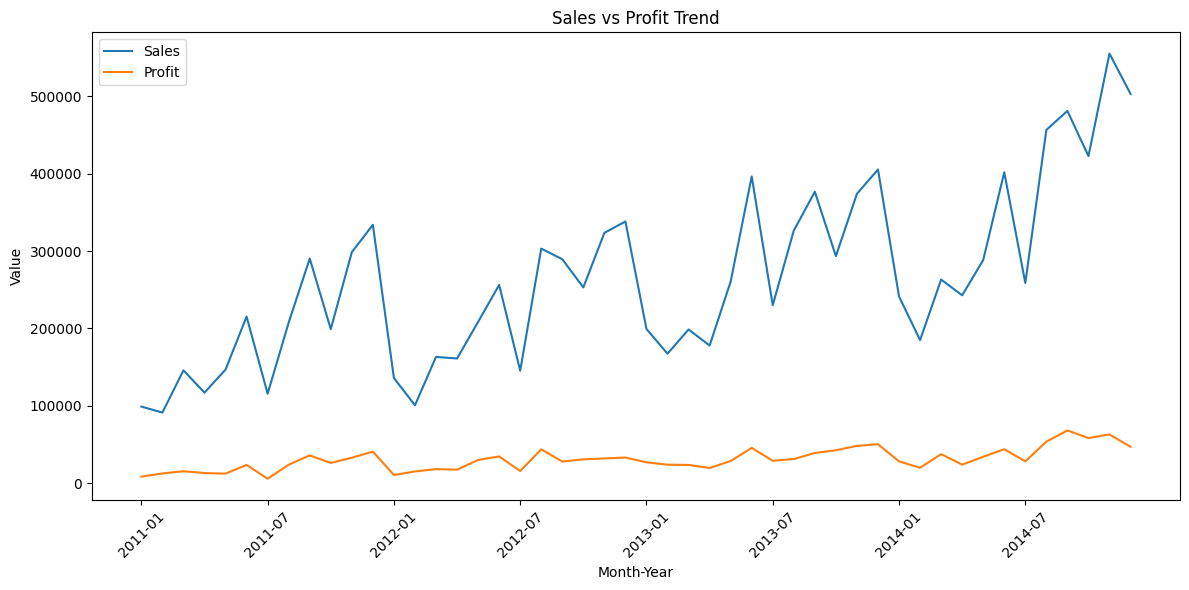

In [83]:
monthly_profit = df.groupby('Month_Year')['Profit'].sum().reset_index()

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales['Month_Year'].astype(str),
    monthly_sales['Sales'],
    label='Sales'
)

plt.plot(
    monthly_profit['Month_Year'].astype(str),
    monthly_profit['Profit'],
    label='Profit'
)

plt.xticks(
    ticks=range(0, len(monthly_sales), 6),
    labels=monthly_sales['Month_Year'].astype(str)[::6],
    rotation=45
)

plt.title("Sales vs Profit Trend")
plt.xlabel("Month-Year")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()

plt.show()

**Category-wise sales**

This graph shows which product category contributes the most to total sales.

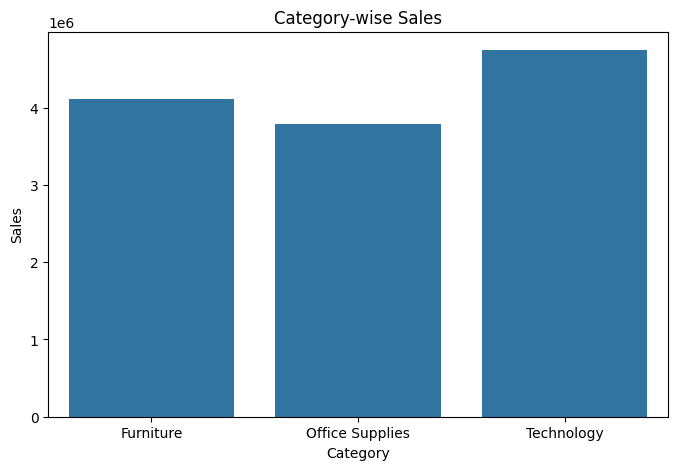

In [84]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=category_sales)

plt.title("Category-wise Sales")
plt.show()

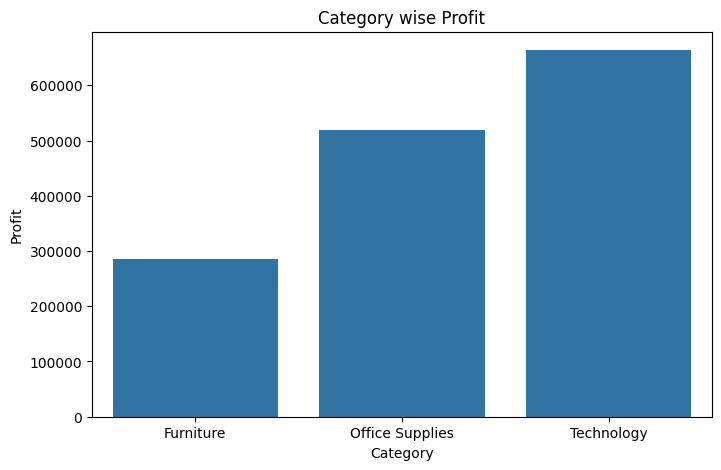

In [85]:
category_profit=df.groupby('Category')['Profit'].sum().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='Category',y='Profit', data=category_profit)
plt.title('Category wise Profit')
plt.show()

**Region-wise sales**

This graph helps in analyzing which geographical region has the highest sales performance.

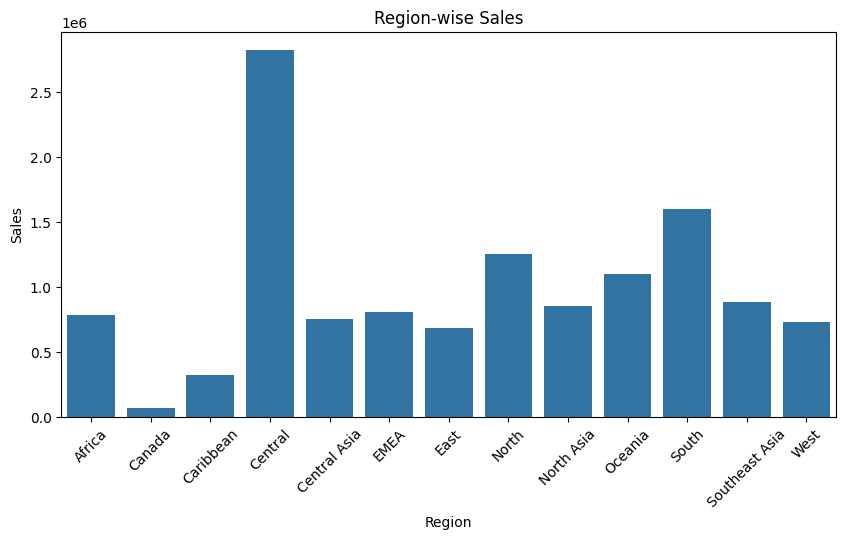

In [86]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(x='Region', y='Sales', data=region_sales)

plt.title("Region-wise Sales")
plt.xticks(rotation=45)

plt.show()

**Year-wise Sales**

This graph shows how sales have changed over the years, helping to identify long-term growth trends.

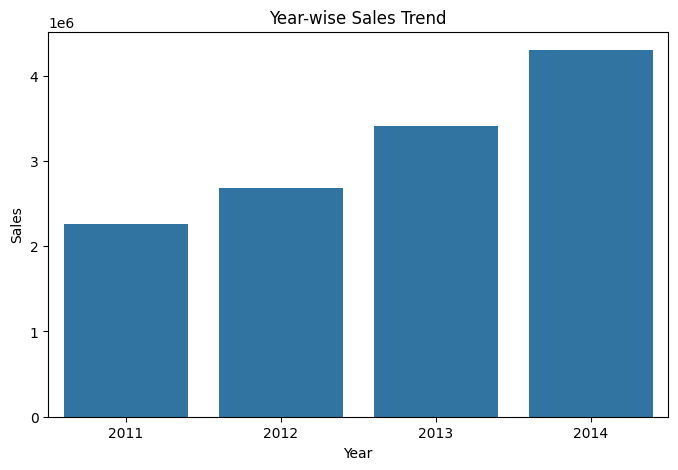

In [87]:
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Year', y='Sales', data=yearly_sales)

plt.title("Year-wise Sales Trend")

plt.show()

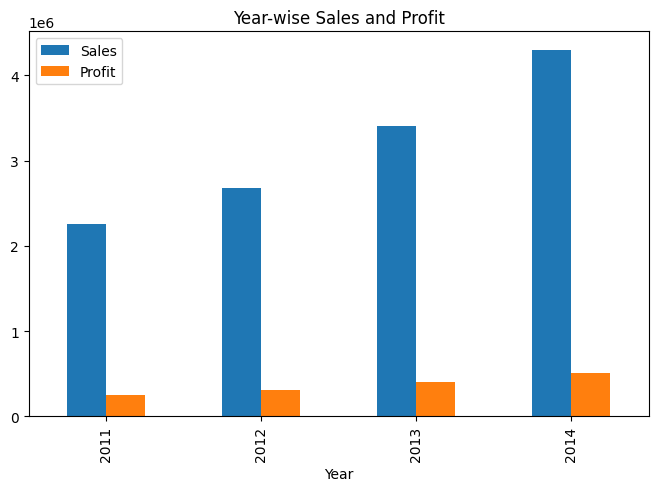

In [88]:
year_data = df.groupby('Year')[['Sales','Profit']].sum()

year_data.plot(kind='bar', figsize=(8,5))
plt.title('Year-wise Sales and Profit')
plt.show()

**HeatMap**

A heatmap was used to visualize sales intensity across different months and years, making it easy to identify peak periods.

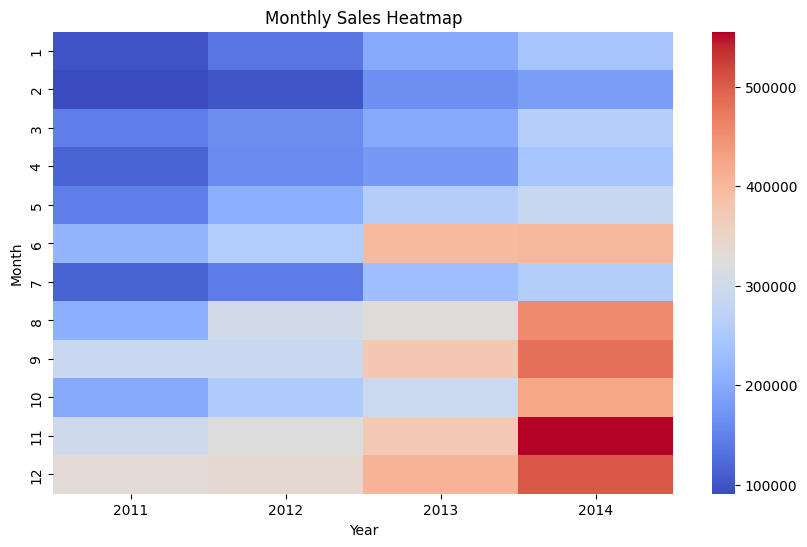

In [89]:
pivot = df.pivot_table(values='Sales', index='Month', columns='Year', aggfunc='sum')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='coolwarm')

plt.title("Monthly Sales Heatmap")

plt.show()

**Statistical Analysis**

Statistical analysis was performed to understand the behavior and variation in sales data. Measures such as mean, maximum, minimum, and standard deviation were calculated. Additionally, growth rate and moving averages were used to analyze trends over time.

In [90]:
print("Mean Sales:", monthly_sales['Sales'].mean())
print("Max Sales:", monthly_sales['Sales'].max())
print("Min Sales:", monthly_sales['Sales'].min())

print("Standard Deviation:", monthly_sales['Sales'].std())

#Basic statistical measures were calculated to understand average sales, variation, and extreme values in the dataset.

Mean Sales: 263393.8541666667
Max Sales: 555312
Min Sales: 91152
Standard Deviation: 113887.3273218324


In [91]:
growth = monthly_sales['Sales'].pct_change() * 100
print(growth)

#Growth rate was calculated to measure the percentage increase or decrease in sales from one month to the next.

0            NaN
1      -7.836040
2      59.871424
3     -19.762431
4      25.515920
5      46.641501
6     -46.324124
7      79.686283
8      39.822710
9     -31.409572
10     49.946752
11     11.873407
12    -59.341620
13    -25.965016
14     62.246695
15     -1.245923
16     29.374146
17     22.945242
18    -43.302977
19    108.718941
20     -4.541526
21    -12.594768
22     27.899677
23      4.554081
24    -41.108664
25    -16.039398
26     18.741143
27    -10.451632
28     46.498158
29     52.197678
30    -42.009468
31     41.989649
32     15.355707
33    -22.091677
34     27.459674
35      8.417202
36    -40.497835
37    -23.384466
38     42.338570
39     -7.726426
40     18.791833
41     39.333366
42    -35.617144
43     76.498350
44      5.376966
45    -12.136887
46     31.346193
47     -9.392558
Name: Sales, dtype: float64


**Future Analysis / Sales Forecasting**

A simple linear regression model was used to forecast future sales based on historical data trends.


In [92]:
import numpy as np

In [93]:
from sklearn.linear_model import LinearRegression
import numpy as np

# create index
monthly_sales['Index'] = np.arange(len(monthly_sales))

# model training
model = LinearRegression()
model.fit(monthly_sales[['Index']], monthly_sales['Sales'])

# future index (WITH column name)
future_index = pd.DataFrame({
    'Index': np.arange(len(monthly_sales), len(monthly_sales)+6)
})

# prediction
future_sales = model.predict(future_index)

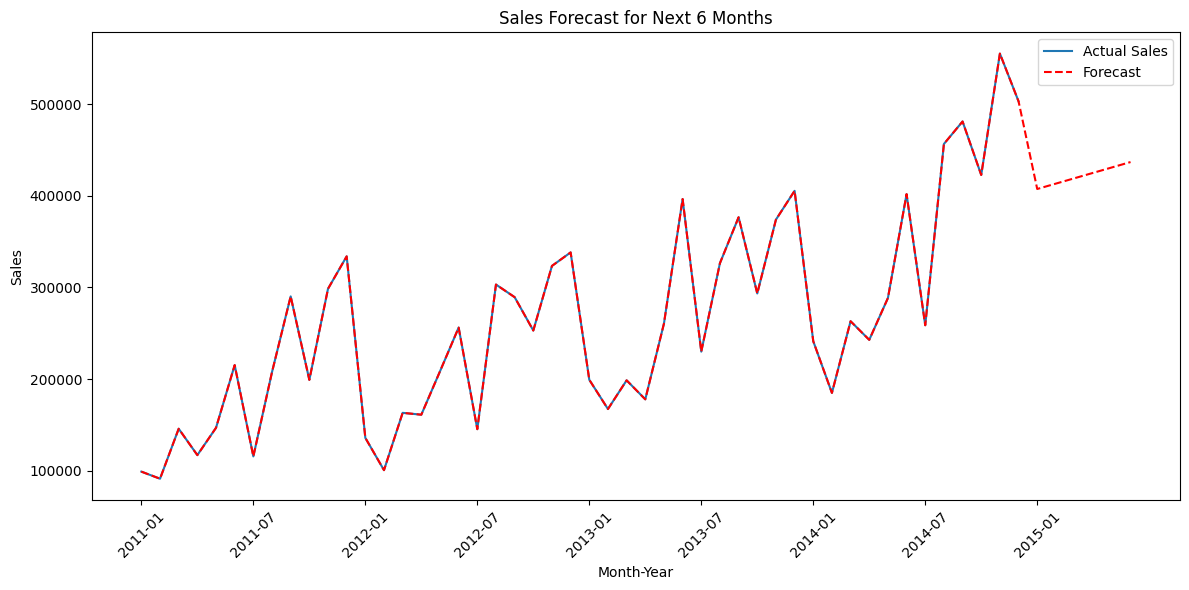

In [94]:
plt.figure(figsize=(12,6))

# Actual sales
plt.plot(
    monthly_sales['Month_Year'].astype(str),
    monthly_sales['Sales'],
    label='Actual Sales'
)

future_months = pd.period_range(
    start=monthly_sales['Month_Year'].iloc[-1] + 1,
    periods=6,
    freq='M'
)

all_months = list(monthly_sales['Month_Year'].astype(str)) + list(future_months.astype(str))
all_sales = list(monthly_sales['Sales']) + list(future_sales)

plt.plot(
    all_months,
    all_sales,
    linestyle='--',
    color='red',
    label='Forecast'
)

plt.xticks(
    ticks=range(0, len(all_months), 6),
    labels=all_months[::6],
    rotation=45
)

plt.title("Sales Forecast for Next 6 Months")
plt.xlabel("Month-Year")
plt.ylabel("Sales")
plt.legend()

plt.tight_layout()

plt.show()

**Actual vs Predicted Comparison Graph**

This graph compares actual sales with predicted values, helping to evaluate the accuracy of the forecasting model.

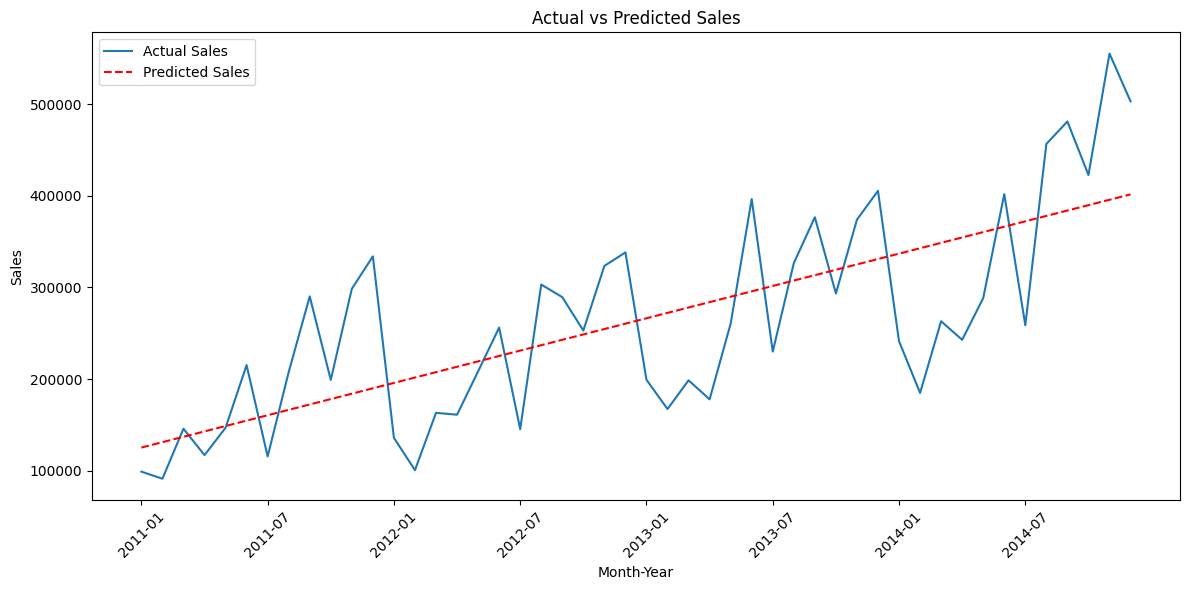

In [97]:
X = np.arange(len(monthly_sales)).reshape(-1, 1)
y = monthly_sales['Sales'].values

model = LinearRegression()
model.fit(X, y)

monthly_sales['Predicted'] = model.predict(X)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales['Month_Year'].astype(str),
    monthly_sales['Sales'],
    label='Actual Sales'
)

plt.plot(
    monthly_sales['Month_Year'].astype(str),
    monthly_sales['Predicted'],
    linestyle='--',
    color='red',
    label='Predicted Sales'
)

plt.xticks(
    ticks=range(0, len(monthly_sales), 6),
    labels=monthly_sales['Month_Year'].astype(str)[::6],
    rotation=45
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Month-Year")
plt.ylabel("Sales")
plt.legend()

plt.tight_layout()
plt.show()

**Future Trend Line**

This graph shows the predicted sales trend for the next six months, providing a clear view of expected future performance.

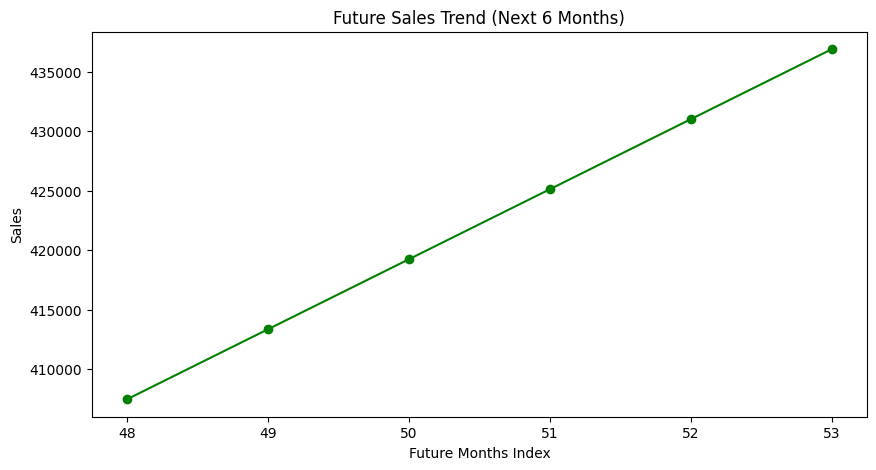

In [98]:
plt.figure(figsize=(10,5))

plt.plot(future_index['Index'], future_sales, marker='o', color='green')

plt.title("Future Sales Trend (Next 6 Months)")
plt.xlabel("Future Months Index")
plt.ylabel("Sales")

plt.show()

In [99]:
# Features & Target
X = df[['Year','Month']]   # independent variables
y = df['Sales']           # dependent variable

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

# Example prediction
year = int(input("Enter Year: "))
month = int(input("Enter Month: "))

prediction = model.predict([[year, month]])
print("Predicted Sales:", prediction[0])

Enter Year: 2027
Enter Month: 6
Predicted Sales: 227.94895491221723


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
